# Imports

In [1]:
# =============================================================================
# Imports
# =============================================================================
import warnings
warnings.filterwarnings("ignore")

import os
import sys
import time
import logging
from pathlib import Path

import numpy as np
import pandas as pd
import scanpy as sc
import anndata as ad
import squidpy as sq
import cellcharter as cc
import scvi
import torch

from lightning.pytorch import seed_everything
from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
    homogeneity_score,
    completeness_score,
    v_measure_score,
)
from scipy.optimize import linear_sum_assignment

# Keep numerical behavior reasonably reproducible on Ampere GPUs.
torch.set_float32_matmul_precision("high")

# USER CONFIGURATION — edit these to match your environment

In [2]:
# =============================================================================
# USER CONFIGURATION — edit these to match your environment
# =============================================================================

# Path to cloned CellCharter repo. This is not strictly required for import if
# the package has been installed, but we keep it here to mirror the previous
# SpaCross / INSTINCT / DLPFC CellCharter notebook format.
CELLCHARTER_ROOT = Path(r"/work/dal875013/projects/mocha/methods/cellcharter")

# Path to the folder containing BC_TNBC_ST .h5ad files.
# Expected files are usually SCE_<sample>.h5ad, but the loader below also
# searches for any *<sample>*.h5ad file if the exact name is different.
DATA_ROOT = Path(r"/groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data")

# Output folder for benchmark results
# This single-sample notebook only writes benchmark.log, performance.parquet, and predictions.parquet.
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter")

# BC_TNBC_ST sample IDs from the dataset README.
# README lists TNBC1-16 and TNBC19-96.
ALL_BC_TNBC_SAMPLES = [
    f"TNBC{i}"
    for i in list(range(1, 17)) + list(range(19, 97))
]

# ----- SUBSET SELECTOR -----------------------------------------------------
# Set SAMPLES_TO_RUN to:
#   - None or "all" -> run all BC_TNBC_ST samples
#   - A list like ["TNBC1", "TNBC2"] -> only run those samples
#   - A single string "TNBC1" -> run just that one
#
# First smoke test suggestion:
# SAMPLES_TO_RUN = "TNBC1"
SAMPLES_TO_RUN = None

# Method name written to parquet files
METHOD_NAME = "CellCharter"

# Number of runs per sample (>1 enables variance estimation)
NUM_RUNS = 1

# Fixed number of BC_TNBC clusters requested for this benchmark.
NUM_CLUSTERS_BC_TNBC = 4

# Which column in adata.obs holds the ground-truth region/domain labels.
# Leave as None to auto-detect from common QuickSRT/AnnData names.
GT_LABEL_COL = None

# =============================================================================
# CellCharter/scVI settings
# =============================================================================

# Method body follows the official CellCharter transcriptomics tutorial pattern:
# counts layer -> scVI latent representation -> squidpy spatial graph ->
# CellCharter aggregate_neighbors -> CellCharter Cluster.
COUNT_LAYER = "counts"
SCVI_LATENT_KEY = "X_scVI"
CELLCHARTER_KEY = "X_cellcharter"
CLUSTER_KEY = "spatial_cluster"
TRUE_LABEL_KEY = "ground_truth"

SCVI_N_LATENT = 10
SCVI_MAX_EPOCHS = None       # None lets scVI use its default heuristic.
SCVI_EARLY_STOPPING = True
SCVI_BATCH_KEY = "sample"    # Single-sample run still has one sample category.

# Use HVGs for speed/memory after saving raw counts in adata.layers["counts"].
USE_HVG = True
N_TOP_GENES = 2000

# Basic filtering, matching the conservative preprocessing style used for DLPFC.
MIN_GENE_COUNTS = 3
MIN_CELL_COUNTS = 3

# CellCharter spatial graph + aggregation
SPATIAL_KEY = "spatial"
SAMPLE_KEY = "sample"
N_LAYERS = 3
USE_DELAUNAY = True
SPATIAL_PERCENTILE = 99
REMOVE_LONG_LINKS = True

# CellCharter GMM clustering
CELLCHARTER_CLUSTER_ON_GPU = True
CELLCHARTER_BATCH_SIZE = None    # Set e.g. 4096 if full-batch GMM uses too much memory.


# =============================================================================
# GPU / device setup
# =============================================================================
def get_device():
    """Return 'cuda:0' if a CUDA GPU is available, else 'cpu'. Logs details."""
    if torch.cuda.is_available():
        dev = "cuda:0"
        os.environ.setdefault("CUDA_VISIBLE_DEVICES", "0")
        logging.info(f"[DEVICE] CUDA available — using {dev}")
        logging.info(f"[DEVICE] GPU name: {torch.cuda.get_device_name(0)}")
        logging.info(
            f"[DEVICE] GPU memory: "
            f"{torch.cuda.get_device_properties(0).total_memory / 1e9:.2f} GB"
        )
    else:
        dev = "cpu"
        logging.warning("[DEVICE] No CUDA GPU detected — falling back to CPU")
    return dev

# Logging setup
def setup_logging(output_dir: Path):
    output_dir.mkdir(parents=True, exist_ok=True)
    log_file = output_dir / "benchmark.log"

    # Reset existing handlers so notebook reruns do not duplicate logs.
    for handler in logging.root.handlers[:]:
        logging.root.removeHandler(handler)

    logging.basicConfig(
        level=logging.INFO,
        format="%(asctime)s | %(levelname)s | %(message)s",
        handlers=[
            logging.FileHandler(log_file, mode="w"),
            logging.StreamHandler(sys.stdout),
        ],
    )
    logging.info(f"[LOG] Writing log to {log_file.resolve()}")

def resolve_samples(samples_to_run):
    """Resolve SAMPLES_TO_RUN into a list of valid sample IDs."""
    if samples_to_run is None or samples_to_run == "all":
        return ALL_BC_TNBC_SAMPLES
    if isinstance(samples_to_run, str):
        samples = [samples_to_run]
    else:
        samples = list(samples_to_run)

    unknown = sorted(set(samples) - set(ALL_BC_TNBC_SAMPLES))
    if unknown:
        raise ValueError(f"Unknown BC_TNBC_ST sample IDs: {unknown}")
    return samples

# Data loading  (adapted for BC_TNBC_ST `.h5ad` input)

In [3]:
# =============================================================================
# Data loading  (adapted for BC_TNBC_ST .h5ad input)
# =============================================================================
def detect_gt_column(adata):
    """Choose the ground-truth label column."""
    if GT_LABEL_COL is not None:
        if GT_LABEL_COL not in adata.obs:
            raise KeyError(
                f"GT_LABEL_COL='{GT_LABEL_COL}' not found. "
                f"Available obs columns: {list(adata.obs.columns)}"
            )
        return GT_LABEL_COL

    candidates = [
        # Common QuickSRT / benchmark names
        "z",
        "label",
        "labels",
        "annotation",
        "annotations",
        "Annotation",
        "manual_annotation",
        "manual_annotations",
        "ground_truth",
        "Ground Truth",
        "truth",
        "region",
        "domain",
        "spatial_domain",
        "cell_type",
        "celltype",
        "tissue",
        "tissue_type",
        "histology",
    ]
    for col in candidates:
        if col in adata.obs:
            return col

    raise KeyError(
        "Could not auto-detect ground-truth label column. "
        f"Available obs columns: {list(adata.obs.columns)}"
    )

def _copy_matrix(X):
    """Copy dense or sparse AnnData matrix without accidentally densifying."""
    return X.copy()

def find_h5ad_path(sample_id: str) -> Path:
    """Find the .h5ad file for a BC_TNBC sample using common QuickSRT patterns."""
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"adata_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}_SCE.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p

    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    if len(matches) > 1:
        raise FileExistsError(
            f"Multiple .h5ad files matched sample {sample_id}: {matches}. "
            "Please set find_h5ad_path() manually."
        )

    raise FileNotFoundError(
        f"Could not find .h5ad file for sample {sample_id} under {DATA_ROOT}. "
        f"Tried: {candidates} and glob '*{sample_id}*.h5ad'."
    )

def prepare_bc_tnbc_adata(sample_id: str):
    """
    Load and preprocess one BC_TNBC_ST .h5ad file for CellCharter single-sample run.

    Data handling mirrors the previous DLPFC/SpaCross style:
      - read one SCE_<sample>.h5ad-style file
      - auto-detect the ground-truth annotation column
      - alias obsm['S'] -> obsm['spatial'] if needed

    Method-specific preprocessing follows the CellCharter transcriptomics tutorial:
      - save raw counts in adata.layers['counts']
      - use scVI on the raw counts layer
      - build spatial graph with squidpy
      - aggregate spatial neighborhoods with CellCharter
    """
    h5ad_path = find_h5ad_path(sample_id)
    logging.info(f"  [LOAD] Reading {h5ad_path}")

    adata = sc.read_h5ad(h5ad_path)
    adata.var_names_make_unique()

    logging.info(
        f"  [DIAG] Loaded AnnData: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )
    logging.info(f"  [DIAG] obs columns: {list(adata.obs.columns)}")
    logging.info(f"  [DIAG] obsm keys  : {list(adata.obsm.keys())}")

    # Ground truth labels
    gt_col = detect_gt_column(adata)
    adata.obs[TRUE_LABEL_KEY] = adata.obs[gt_col].astype(object)
    n_labeled = int(adata.obs[TRUE_LABEL_KEY].notna().sum())
    logging.info(
        f"  [DIAG] Using GT column '{gt_col}' "
        f"(labeled spots: {n_labeled}/{adata.n_obs})"
    )
    logging.info(
        f"  [DIAG] GT label counts: "
        f"{adata.obs[TRUE_LABEL_KEY].astype(str).value_counts(dropna=False).to_dict()}"
    )

    # Add sample metadata; this keeps code compatible with CellCharter's
    # sample_key/library_key logic, even for one-sample-one-model runs.
    adata.obs[SAMPLE_KEY] = pd.Categorical([sample_id] * adata.n_obs)

    # Spatial coordinates. QuickSRT datasets often use obsm['S'].
    if SPATIAL_KEY not in adata.obsm:
        if "S" in adata.obsm:
            adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm["S"])
            logging.info(f"  [DIAG] Aliased obsm['S'] -> obsm['{SPATIAL_KEY}']")
        else:
            raise KeyError(
                f"No spatial coordinates found in {h5ad_path}. "
                f"Available obsm keys: {list(adata.obsm.keys())}"
            )
    else:
        adata.obsm[SPATIAL_KEY] = np.asarray(adata.obsm[SPATIAL_KEY])

    logging.info(
        f"  [DIAG] spatial coords shape: {adata.obsm[SPATIAL_KEY].shape}"
    )

    # Basic count filtering.
    sc.pp.filter_genes(adata, min_counts=MIN_GENE_COUNTS)
    sc.pp.filter_cells(adata, min_counts=MIN_CELL_COUNTS)
    logging.info(
        f"  [DIAG] After basic filtering: n_obs={adata.n_obs}, n_vars={adata.n_vars}"
    )

    # Save raw count matrix for scVI before normalization/log transform.
    adata.layers[COUNT_LAYER] = _copy_matrix(adata.X)

    # Normalize/log for HVG selection and inspection. scVI will use counts layer.
    sc.pp.normalize_total(adata, target_sum=1e6)
    sc.pp.log1p(adata)

    if USE_HVG:
        n_top = min(N_TOP_GENES, adata.n_vars)
        sc.pp.highly_variable_genes(
            adata,
            n_top_genes=n_top,
            flavor="seurat",
        )
        n_hvg = int(adata.var["highly_variable"].sum())
        logging.info(f"  [DIAG] HVGs selected: {n_hvg}/{adata.n_vars}")
        adata = adata[:, adata.var["highly_variable"]].copy()
        logging.info(f"  [DIAG] After HVG subset: n_obs={adata.n_obs}, n_vars={adata.n_vars}")

    return adata, gt_col

# Metrics helpers

In [4]:
# =============================================================================
# Metrics helpers
# =============================================================================
def clustering_accuracy(y_true, y_pred):
    """
    Clustering accuracy after optimal label matching via Hungarian algorithm.
    This is useful as a simple ACC column comparable across unsupervised runs.
    """
    y_true = pd.Series(y_true).astype(str).to_numpy()
    y_pred = pd.Series(y_pred).astype(str).to_numpy()

    true_classes = pd.Index(sorted(pd.unique(y_true)))
    pred_classes = pd.Index(sorted(pd.unique(y_pred)))

    contingency = np.zeros((len(true_classes), len(pred_classes)), dtype=np.int64)
    true_map = {c: i for i, c in enumerate(true_classes)}
    pred_map = {c: j for j, c in enumerate(pred_classes)}

    for t, p in zip(y_true, y_pred):
        contingency[true_map[t], pred_map[p]] += 1

    # Maximize correct assignments. linear_sum_assignment minimizes cost.
    row_ind, col_ind = linear_sum_assignment(-contingency)
    return contingency[row_ind, col_ind].sum() / contingency.sum()

def compute_metrics(adata, label_key=TRUE_LABEL_KEY, pred_key=CLUSTER_KEY):
    """Compute metrics on labeled spots only."""
    labeled_mask = adata.obs[label_key].notna()
    sub = adata[labeled_mask].copy()

    if sub.n_obs == 0:
        return {
            "ARI": np.nan,
            "NMI": np.nan,
            "ACC": np.nan,
            "HOM": np.nan,
            "COM": np.nan,
            "V_measure": np.nan,
        }, sub

    y_true = sub.obs[label_key].astype(str).to_numpy()
    y_pred = sub.obs[pred_key].astype(str).to_numpy()

    metrics = {
        "ARI": float(adjusted_rand_score(y_true, y_pred)),
        "NMI": float(normalized_mutual_info_score(y_true, y_pred)),
        "ACC": float(clustering_accuracy(y_true, y_pred)),
        "HOM": float(homogeneity_score(y_true, y_pred)),
        "COM": float(completeness_score(y_true, y_pred)),
        "V_measure": float(v_measure_score(y_true, y_pred)),
    }
    return metrics, sub

# Train one BC_TNBC sample

In [5]:
# =============================================================================
# Train one BC_TNBC sample
# =============================================================================
def train_one_sample(
    sample_id: str,
    adata,
    device: str,
    run_seed: int = 0,
):
    """
    Run CellCharter on one BC_TNBC_ST sample and compute ARI/NMI/ACC.

    Method body follows the official CellCharter transcriptomics workflow:
        counts layer
        -> scVI latent representation
        -> squidpy spatial_neighbors
        -> optional CellCharter remove_long_links
        -> CellCharter aggregate_neighbors
        -> CellCharter GMM Cluster with fixed K=4

    Returns:
        metrics: dict of scalar metrics + timing
        pred_df: DataFrame with one row per spot:
            method, sample, spot_id, true_label, pred_label, run_seed
    """
    num_clusters = NUM_CLUSTERS_BC_TNBC
    logging.info(
        f"  [TRAIN] Starting CellCharter single-sample | sample={sample_id} | "
        f"k_clusters={num_clusters} | device={device} | run_seed={run_seed}"
    )

    seed_everything(run_seed, workers=True)
    scvi.settings.seed = run_seed
    np.random.seed(run_seed)
    torch.manual_seed(run_seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(run_seed)

    t0 = time.time()

    # ---------------------------------------------------------------------
    # 1) scVI dimensionality reduction
    # ---------------------------------------------------------------------
    logging.info("  [SCVI] setup_anndata")
    scvi.model.SCVI.setup_anndata(
        adata,
        layer=COUNT_LAYER,
        batch_key=SCVI_BATCH_KEY,
    )

    logging.info(
        f"  [SCVI] Training SCVI(n_latent={SCVI_N_LATENT}, "
        f"max_epochs={SCVI_MAX_EPOCHS}, early_stopping={SCVI_EARLY_STOPPING})"
    )
    model = scvi.model.SCVI(
        adata,
        n_latent=SCVI_N_LATENT,
    )

    train_kwargs = dict(
        early_stopping=SCVI_EARLY_STOPPING,
        enable_progress_bar=True,
    )
    if SCVI_MAX_EPOCHS is not None:
        train_kwargs["max_epochs"] = SCVI_MAX_EPOCHS

    try:
        model.train(**train_kwargs)
    except TypeError:
        # Compatibility fallback for older/newer scvi-tools trainer signatures.
        logging.warning("  [SCVI] train_kwargs failed; retrying with explicit train()")
        model.train(
            max_epochs=SCVI_MAX_EPOCHS,
            early_stopping=SCVI_EARLY_STOPPING,
            enable_progress_bar=True,
        )

    adata.obsm[SCVI_LATENT_KEY] = model.get_latent_representation(adata).astype(np.float32)
    logging.info(f"  [DIAG] {SCVI_LATENT_KEY} shape: {adata.obsm[SCVI_LATENT_KEY].shape}")

    # ---------------------------------------------------------------------
    # 2) Spatial graph, following CellCharter tutorials
    # ---------------------------------------------------------------------
    logging.info("  [GRAPH] squidpy.gr.spatial_neighbors")
    sq.gr.spatial_neighbors(
        adata,
        library_key=SAMPLE_KEY,
        coord_type="generic",
        delaunay=USE_DELAUNAY,
        spatial_key=SPATIAL_KEY,
        percentile=SPATIAL_PERCENTILE,
    )

    if REMOVE_LONG_LINKS:
        logging.info("  [GRAPH] cellcharter.gr.remove_long_links")
        try:
            cc.gr.remove_long_links(adata)
        except Exception as e:
            logging.warning(f"  [GRAPH] remove_long_links failed; continuing. Error: {e}")

    # ---------------------------------------------------------------------
    # 3) CellCharter neighborhood aggregation
    # ---------------------------------------------------------------------
    logging.info(
        f"  [CC] aggregate_neighbors(n_layers={N_LAYERS}, use_rep={SCVI_LATENT_KEY})"
    )
    cc.gr.aggregate_neighbors(
        adata,
        n_layers=N_LAYERS,
        use_rep=SCVI_LATENT_KEY,
        out_key=CELLCHARTER_KEY,
        sample_key=SAMPLE_KEY,
    )
    logging.info(f"  [DIAG] {CELLCHARTER_KEY} shape: {adata.obsm[CELLCHARTER_KEY].shape}")

    # ---------------------------------------------------------------------
    # 4) CellCharter GMM clustering
    # ---------------------------------------------------------------------
    if CELLCHARTER_CLUSTER_ON_GPU and torch.cuda.is_available():
        trainer_params = dict(accelerator="gpu", devices=1, enable_progress_bar=True)
    else:
        trainer_params = dict(accelerator="cpu", enable_progress_bar=True)

    logging.info("  [CC] Fitting CellCharter Cluster")
    gmm = cc.tl.Cluster(
        n_clusters=num_clusters,
        random_state=run_seed,
        batch_size=CELLCHARTER_BATCH_SIZE,
        trainer_params=trainer_params,
    )
    gmm.fit(adata, use_rep=CELLCHARTER_KEY)
    pred_labels = gmm.predict(adata, use_rep=CELLCHARTER_KEY)

    # Store as string category for clean parquet/plotting
    adata.obs[CLUSTER_KEY] = pd.Categorical(
        pd.Series(pred_labels, index=adata.obs_names).astype(str)
    )

    logging.info(
        f"  [DIAG] Cluster sizes: "
        f"{adata.obs[CLUSTER_KEY].astype(str).value_counts().to_dict()}"
    )

    elapsed = time.time() - t0

    # ---------------------------------------------------------------------
    # 5) Metrics
    # ---------------------------------------------------------------------
    metric_vals, sub_adata = compute_metrics(adata, TRUE_LABEL_KEY, CLUSTER_KEY)

    gpu_name = torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU"

    metrics = {
        "method": METHOD_NAME,
        "sample": sample_id,
        "training_unit": sample_id,
        "run_seed": run_seed,
        **metric_vals,
        # Keep DIS column for compatibility with older SpaCross-style summaries.
        # CellCharter itself does not output SpaCross DIS, so leave it as NaN.
        "DIS": np.nan,
        "running_time_sec": round(elapsed, 2),
        "unit_running_time_sec": round(elapsed, 2),
        "gpu_model": gpu_name,
        "num_clusters": int(num_clusters),
        "num_spots": int(adata.n_obs),
        "num_labeled_spots": int(sub_adata.n_obs),
        "num_genes_after_hvg": int(adata.n_vars),
        "scvi_n_latent": int(SCVI_N_LATENT),
        "cellcharter_dim": int(adata.obsm[CELLCHARTER_KEY].shape[1]),
        "n_layers": int(N_LAYERS),
        "cluster_key": CLUSTER_KEY,
        "device": device,
    }

    pred_df = pd.DataFrame({
        "method": METHOD_NAME,
        "sample": sample_id,
        "training_unit": sample_id,
        "spot_id": adata.obs_names.astype(str),
        "true_label": adata.obs[TRUE_LABEL_KEY].astype(object).values,
        "pred_label": adata.obs[CLUSTER_KEY].astype(str).values,
        "run_seed": run_seed,
    })

    return metrics, pred_df

# Main benchmark loop

In [6]:
# =============================================================================
# Main benchmark loop
# =============================================================================
def run_benchmark():
    setup_logging(OUTPUT_DIR)

    logging.info("=" * 72)
    logging.info("CellCharter BC_TNBC_ST Benchmarking Framework")
    logging.info("=" * 72)

    # --- Optional local repo sanity check ---
    if CELLCHARTER_ROOT.exists():
        logging.info(f"[PATHS] CELLCHARTER_ROOT = {CELLCHARTER_ROOT.resolve()}")
        # Only add if you want to use local source before installed wheel.
        if str(CELLCHARTER_ROOT.resolve()) not in sys.path:
            sys.path.insert(0, str(CELLCHARTER_ROOT.resolve()))
    else:
        logging.warning(f"[PATHS] CELLCHARTER_ROOT not found: {CELLCHARTER_ROOT}")

    # --- Device ---
    device = get_device()

    # --- Data root sanity check ---
    if not DATA_ROOT.exists():
        raise FileNotFoundError(f"DATA_ROOT not found: {DATA_ROOT.resolve()}")

    logging.info(f"[PATHS] DATA_ROOT  = {DATA_ROOT.resolve()}")
    logging.info(f"[PATHS] OUTPUT_DIR = {OUTPUT_DIR.resolve()}")

    logging.info(f"[VERSIONS] cellcharter = {getattr(cc, '__version__', cc.__file__)}")
    logging.info(f"[VERSIONS] scvi        = {scvi.__version__}")
    logging.info(f"[VERSIONS] scanpy      = {sc.__version__}")
    logging.info(f"[VERSIONS] squidpy     = {sq.__version__}")
    logging.info(f"[VERSIONS] torch       = {torch.__version__}")

    # --- Which samples to run ---
    samples = resolve_samples(SAMPLES_TO_RUN)
    logging.info(f"[SAMPLES] Will process {len(samples)} sample(s): {samples}")
    logging.info(
        f"[SETTINGS] NUM_RUNS={NUM_RUNS} | K={NUM_CLUSTERS_BC_TNBC} | "
        f"SCVI_N_LATENT={SCVI_N_LATENT} | N_LAYERS={N_LAYERS} | USE_HVG={USE_HVG}"
    )

    all_metrics = []
    all_predictions = []
    failed = []

    for i, sample_id in enumerate(samples, start=1):
        logging.info("")
        logging.info("-" * 72)
        logging.info(f"[{i}/{len(samples)}] BC_TNBC sample {sample_id}")
        logging.info("-" * 72)

        try:
            adata, gt_col = prepare_bc_tnbc_adata(sample_id)

            for run in range(NUM_RUNS):
                logging.info(f"  -> Run {run + 1}/{NUM_RUNS}")
                adata_run = adata.copy()  # avoid cross-run contamination

                metrics, pred_df = train_one_sample(
                    sample_id=sample_id,
                    adata=adata_run,
                    device=device,
                    run_seed=run,
                )
                metrics["gt_col"] = gt_col
                all_metrics.append(metrics)
                all_predictions.append(pred_df)

            if torch.cuda.is_available():
                torch.cuda.empty_cache()

        except Exception as e:
            logging.exception(f"[FAILED] Sample {sample_id}: {e}")
            failed.append({"sample": sample_id, "error": str(e)})
            continue

    # =====================================================================
    # Save outputs
    # =====================================================================
    OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

    if all_metrics:
        performance = pd.DataFrame(all_metrics)
        performance_path = OUTPUT_DIR / "performance.parquet"
        performance.to_parquet(performance_path, index=False)
        logging.info(f"[SAVE] performance -> {performance_path}")

        logging.info("[RESULTS] Performance table:")
        logging.info("\n" + performance.to_string(index=False))
    else:
        performance = pd.DataFrame()
        logging.warning("[SAVE] No successful metrics to save.")

    if all_predictions:
        predictions = pd.concat(all_predictions, ignore_index=True)
        pred_path = OUTPUT_DIR / "predictions.parquet"
        predictions.to_parquet(pred_path, index=False)
        logging.info(f"[SAVE] predictions -> {pred_path}")
    else:
        predictions = pd.DataFrame()
        logging.warning("[SAVE] No predictions to save.")

    if failed:
        logging.warning(f"[FAILED] Some samples failed: {failed}")
    else:
        logging.info("[DONE] All requested samples completed successfully.")

    return performance, predictions, failed

# Actually run benchmark
performance, predictions, failed = run_benchmark()

2026-05-18 00:27:46,762 | INFO | [LOG] Writing log to /work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter/benchmark.log
2026-05-18 00:27:46,762 | INFO | ========================================================================
2026-05-18 00:27:46,764 | INFO | CellCharter BC_TNBC_ST Benchmarking Framework
2026-05-18 00:27:46,765 | INFO | ========================================================================
2026-05-18 00:27:46,765 | INFO | [PATHS] CELLCHARTER_ROOT = /work/dal875013/projects/mocha/methods/cellcharter
2026-05-18 00:27:46,790 | INFO | [DEVICE] CUDA available — using cuda:0
2026-05-18 00:27:46,843 | INFO | [DEVICE] GPU name: NVIDIA A30
2026-05-18 00:27:46,844 | INFO | [DEVICE] GPU memory: 25.22 GB
2026-05-18 00:27:46,853 | INFO | [PATHS] DATA_ROOT  = /groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data
2026-05-18 00:27:46,854 | INFO | [PATHS] OUTPUT_DIR = /work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter
2026-05-18 00:27:46,855 | INFO | [VER

[rank: 0] Seed set to 0
[rank: 0] Seed set to 0


2026-05-18 00:27:48,339 | INFO |   [SCVI] setup_anndata
2026-05-18 00:27:48,341 | INFO |   [SCVI] Training SCVI(n_latent=10, max_epochs=None, early_stopping=True)


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


Epoch 188/400:  47%|████▋     | 188/400 [00:18<00:21,  9.95it/s, v_num=1, train_loss=907]  
Monitored metric elbo_validation did not improve in the last 45 records. Best score: 983.834. Signaling Trainer to stop.
2026-05-18 00:28:08,679 | INFO |   [DIAG] X_scVI shape: (922, 10)
2026-05-18 00:28:08,686 | INFO |   [GRAPH] squidpy.gr.spatial_neighbors
INFO     Creating graph using `generic` coordinates and `None` transform and `1` libraries.                        
2026-05-18 00:28:08,957 | INFO |   [GRAPH] cellcharter.gr.remove_long_links
2026-05-18 00:28:08,965 | INFO |   [CC] aggregate_neighbors(n_layers=3, use_rep=X_scVI)


...

100%|██████████| 4/4 [00:00<00:00, 1618.17it/s]

2026-05-18 00:48:23,108 | INFO |   [DIAG] X_cellcharter shape: (1222, 40)
2026-05-18 00:48:23,108 | INFO |   [CC] Fitting CellCharter Cluster



LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
LOCAL_RANK: 0 - CUDA_VISIBLE_DEVICES: [0]
SLURM auto-requeueing enabled. Setting signal handlers.


2026-05-18 00:48:25,063 | INFO |   [DIAG] Cluster sizes: {'0': 463, '1': 362, '2': 293, '3': 104}
2026-05-18 00:48:25,138 | INFO | [SAVE] performance -> /work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter/performance.parquet
2026-05-18 00:48:25,139 | INFO | [RESULTS] Performance table:
2026-05-18 00:48:25,150 | INFO | 
     method sample training_unit  run_seed      ARI      NMI      ACC      HOM      COM  V_measure  DIS  running_time_sec  unit_running_time_sec  gpu_model  num_clusters  num_spots  num_labeled_spots  num_genes_after_hvg  scvi_n_latent  cellcharter_dim  n_layers     cluster_key device gt_col
CellCharter  TNBC1         TNBC1         0 0.089706 0.180103 0.413232 0.196245 0.166414   0.180103  NaN             23.57                  23.57 NVIDIA A30             4        922                922                 2000             10               40         3 spatial_cluster cuda:0      z
CellCharter  TNBC2         TNBC2         0 0.458485 0.494440 0.664799 0.54

# Prediction results visualization

... storing 'true_label' as categorical
... storing 'pred_label' as categorical


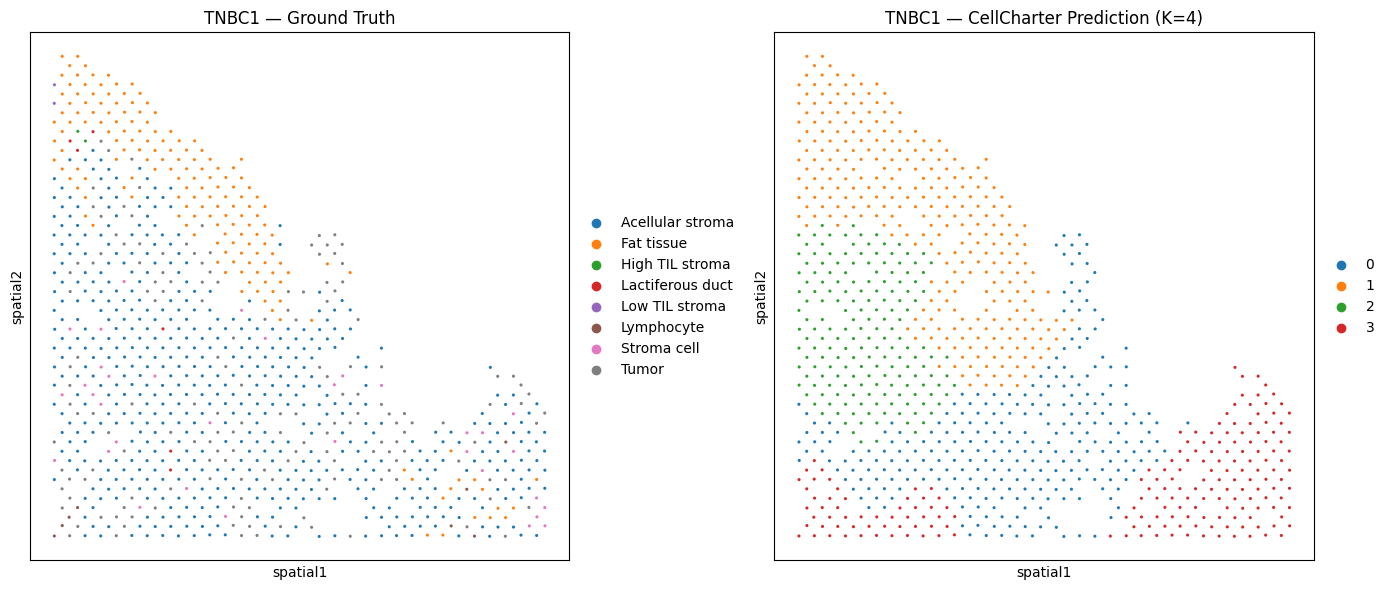

In [7]:
import pandas as pd
import numpy as np
import scanpy as sc
import matplotlib.pyplot as plt
from pathlib import Path

DATA_ROOT  = Path(r"/groups/qiwei/mocha/QuickSRT/BC_TNBC_ST/data")
OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter")

SAMPLE_ID = "TNBC1"

predictions = pd.read_parquet(OUTPUT_DIR / "predictions.parquet")
pred_slice = predictions[predictions["sample"] == SAMPLE_ID].set_index("spot_id")

# Reuse the same path resolver pattern for visualization.
def find_h5ad_path_for_plot(sample_id):
    candidates = [
        DATA_ROOT / f"SCE_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}.h5ad",
        DATA_ROOT / f"adata_{sample_id}.h5ad",
        DATA_ROOT / f"{sample_id}_SCE.h5ad",
    ]
    for p in candidates:
        if p.exists():
            return p
    matches = sorted(DATA_ROOT.glob(f"*{sample_id}*.h5ad"))
    if len(matches) == 1:
        return matches[0]
    raise FileNotFoundError(f"Cannot find unique h5ad file for {sample_id}")

adata = sc.read_h5ad(find_h5ad_path_for_plot(SAMPLE_ID))
adata.obs["true_label"] = pred_slice["true_label"].reindex(adata.obs_names).values
adata.obs["pred_label"] = pred_slice["pred_label"].reindex(adata.obs_names).values

if "spatial" not in adata.obsm and "S" in adata.obsm:
    adata.obsm["spatial"] = np.asarray(adata.obsm["S"])

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

sc.pl.embedding(
    adata,
    basis="spatial",
    color="true_label",
    ax=axes[0],
    show=False,
    title=f"{SAMPLE_ID} — Ground Truth",
    s=20,
)

sc.pl.embedding(
    adata,
    basis="spatial",
    color="pred_label",
    ax=axes[1],
    show=False,
    title=f"{SAMPLE_ID} — CellCharter Prediction (K=4)",
    s=20,
)

axes[0].invert_yaxis()
axes[1].invert_yaxis()
plt.tight_layout()
plt.show()

# Running results summary

In [ ]:
import pandas as pd
from pathlib import Path

OUTPUT_DIR = Path(r"/work/dal875013/projects/mocha/results/CellCharter/bc_tnbc_cellcharter")

perf_path = OUTPUT_DIR / "performance.parquet"

if not perf_path.exists():
    raise FileNotFoundError(f"Cannot find {perf_path}")

performance = pd.read_parquet(perf_path)
performance = performance.sort_values(["sample", "run_seed"]).reset_index(drop=True)

display_cols = [
    "sample", "run_seed", "ARI", "NMI", "ACC", "HOM", "COM", "V_measure",
    "num_clusters", "num_spots", "num_labeled_spots",
    "num_genes_after_hvg", "scvi_n_latent", "cellcharter_dim", "n_layers",
    "running_time_sec", "gpu_model"
]
display_cols = [c for c in display_cols if c in performance.columns]

print("===== All BC_TNBC_ST CellCharter single-sample results =====")
display(performance[display_cols])

print("\n===== Summary =====")
metric_cols = [c for c in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure", "running_time_sec"] if c in performance.columns]
display(performance[metric_cols].describe())

print("\n===== Mean metrics =====")
for col in ["ARI", "NMI", "ACC", "HOM", "COM", "V_measure"]:
    if col in performance.columns:
        print(f"Mean {col}: {performance[col].mean():.4f}")

print("\n===== Best / worst ARI =====")
if "ARI" in performance.columns and len(performance) > 0:
    best = performance.loc[performance["ARI"].idxmax()]
    worst = performance.loc[performance["ARI"].idxmin()]
    print(f"Best ARI : {best['sample']}  ARI={best['ARI']:.4f}")
    print(f"Worst ARI: {worst['sample']}  ARI={worst['ARI']:.4f}")

===== All BC_TNBC_ST CellCharter single-sample results =====


,sample,run_seed,ARI,NMI,ACC,HOM,COM,V_measure,num_clusters,num_spots,num_labeled_spots,num_genes_after_hvg,scvi_n_latent,cellcharter_dim,n_layers,running_time_sec,gpu_model
0,TNBC1,0,0.089706,0.180103,0.413232,0.196245,0.166414,0.180103,4,922,922,2000,10,40,3,23.57,NVIDIA A30
1,TNBC10,0,0.155430,0.187833,0.551929,0.226536,0.160425,0.187833,4,674,674,2000,10,40,3,13.77,NVIDIA A30
2,TNBC11,0,0.038247,0.058721,0.404194,0.095412,0.042412,0.058721,4,1049,1049,2000,10,40,3,16.67,NVIDIA A30
3,TNBC12,0,0.310364,0.344700,0.568627,0.402691,0.301309,0.344700,4,816,816,2000,10,40,3,15.31,NVIDIA A30
4,TNBC13,0,0.205469,0.254784,0.599412,0.347693,0.201058,0.254784,4,1021,1021,2000,10,40,3,16.64,NVIDIA A30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
89,TNBC92,0,0.132282,0.196498,0.365854,0.198660,0.194382,0.196498,4,779,779,2000,10,40,3,12.55,NVIDIA A30
90,TNBC93,0,0.065197,0.177960,0.373308,0.355416,0.118696,0.177960,4,517,517,2000,10,40,3,10.25,NVIDIA A30
91,TNBC94,0,0.069166,0.103169,0.389373,0.114856,0.093640,0.103169,4,1148,1148,2000,10,40,3,14.85,NVIDIA A30
92,TNBC95,0,0.082290,0.081723,0.445286,0.106973,0.066117,0.081723,4,1453,1453,2000,10,40,3,10.16,NVIDIA A30



===== Summary =====


,ARI,NMI,ACC,HOM,COM,V_measure,running_time_sec
count,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000,94.000000
mean,0.157555,0.216802,0.454627,0.234413,0.208302,0.216802,12.609362
std,0.127738,0.128312,0.095232,0.129051,0.136162,0.128312,4.445065
min,0.005038,0.015686,0.307087,0.022214,0.012124,0.015686,3.500000
25%,0.065326,0.113063,0.379728,0.129292,0.102435,0.113063,9.500000
50%,0.118291,0.194090,0.433387,0.210166,0.177765,0.194090,12.180000
75%,0.212540,0.289929,0.529975,0.311750,0.268202,0.289929,15.067500
max,0.565726,0.580824,0.727829,0.604555,0.653998,0.580824,27.810000



===== Mean metrics =====
Mean ARI: 0.1576
Mean NMI: 0.2168
Mean ACC: 0.4546
Mean HOM: 0.2344
Mean COM: 0.2083
Mean V_measure: 0.2168

===== Best / worst ARI =====
Best ARI : TNBC22  ARI=0.5657
Worst ARI: TNBC53  ARI=0.0050


: 